# PERCOBAAN 2
grayscale, resize, dan gaussian blur

In [19]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rembg import remove
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [20]:
data = []
labels = []
file_name = []

dataset_path = "." 

target_folders = ["Brokoli", "Kembang Kol"]

for sub_folder in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, sub_folder)

    # Validasi: Pastikan itu adalah folder DAN termasuk dalam target_folders kita
    if not os.path.isdir(full_path) or sub_folder not in target_folders:
        continue  

    sub_folder_files = os.listdir(full_path)
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join(full_path, filename)
        
        img = cv.imread(img_path)
        if img is not None:
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            img = cv.resize(img, (256, 256))  # Resize ke ukuran tetap
            img = img.astype(np.uint8)

            data.append(img)
            labels.append(sub_folder)
            name = os.path.splitext(filename)[0]
            file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

# Opsional: Cetak jumlah data untuk memastikan loading berhasil
print(f"Total data gambar berhasil dimuat: {len(data)}")
print(f"Distribusi label: {np.unique(labels, return_counts=True)}")

Total data gambar berhasil dimuat: 200
Distribusi label: (array(['Brokoli', 'Kembang Kol'], dtype='<U11'), array([100, 100]))


## Data Preparation

### Data Preprocessing

In [21]:
def removeBackground(img):
    if img is None:
        return None
        
    img_removed = remove(img) 
    img_removed_rgb = cv.cvtColor(img_removed, cv.COLOR_RGBA2RGB)
    return img_removed_rgb

In [22]:
def grayscale(image):
    if len(image.shape) == 2:
        return image
    elif len(image.shape) == 3:
        r, g, b = image[:,:,0], image[:,:,1], image[:,:,2]
        gray_image = 0.299 * r + 0.587 * g + 0.114 * b
        return gray_image.astype(np.uint8)
    else:
        raise ValueError("Input image must be either grayscale or RGB")

In [23]:
def resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]

    resized_image = np.zeros(
        (new_height, new_width),
        dtype=np.uint8
    )

    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)

            resized_image[i, j] = image[y, x]

    return resized_image

In [24]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size
    padded = np.pad(img, pad_size, mode='constant')

    canvas = np.zeros_like(img).astype(np.float32)
    h, w = img.shape

    for i in range(h):
        for j in range(w):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    
    return canvas

# kernel smoothing
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5, 1/10],
    [1/10, 1/10, 1/10]
])

### Preprocessing

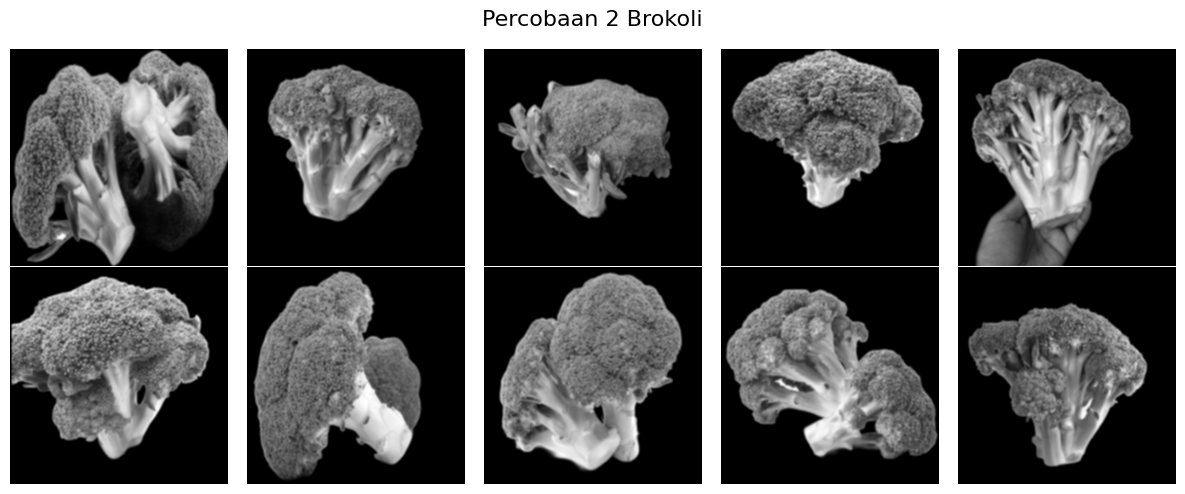

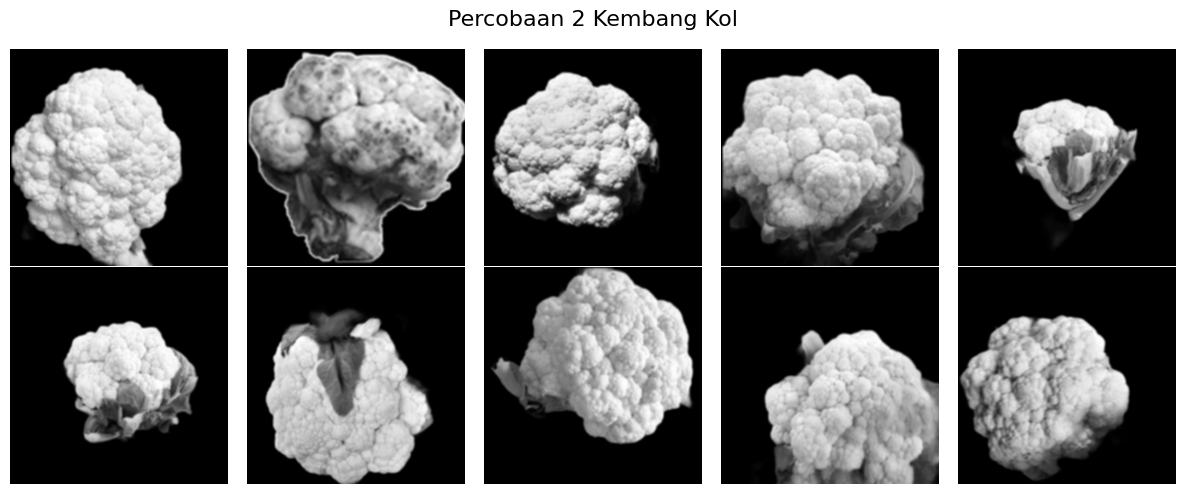

In [25]:
def percobaan2(img):
    img_no_bg = removeBackground(img)
    img_gray = grayscale(img_no_bg)
    img_resize = resize(img_gray, 256, 256)
    img_smoothing = convolution(img_resize, kernelSmoothing)
    return img_smoothing

dataPreprocessed = [percobaan2(img) for img in data]  

unique_labels = sorted(set(labels))

for label in unique_labels:
    # Ambil semua indeks gambar dari label ini
    idxs = [j for j, l in enumerate(labels) if l == label]
    
    # Buat grid 7x12 (cukup untuk 84 gambar, 7*12 = 84)
    fig, axs = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(f'Percobaan 2 {label}', fontsize=16)
    
    for k in range(10):
        row = k // 5
        col = k % 5
        ax = axs[row][col]
        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # beri ruang untuk judul
    plt.show()

### Ekstraksi Fitur

In [26]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [27]:
def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [28]:
def ekstrak_fitur_glcm(data, nama_prepro):
    fitur_list = []
    for img in data:
        img_u8 = img.astype(np.uint8)
        m = glcm(img_u8, 0)  # derajat 0
        
        fitur = {
            'contrast': contrast(m),
            'correlation': correlation(m),
            'energy': energy(m),
            'homogeneity': homogenity(m),
            'dissimilarity': dissimilarity(m),
            'ASM': ASM(m),
            'entropy': entropyGlcm(m)
        }
        fitur_list.append(fitur)

    df = pd.DataFrame(fitur_list)
    df['tahap'] = nama_prepro
    return df

df2 = ekstrak_fitur_glcm(dataPreprocessed, 'percobaan2')
display(df2)

,contrast,correlation,energy,homogeneity,dissimilarity,ASM,entropy,tahap
0,121.632261,0.986339,0.240160,0.359448,6.651593,0.057677,7.376831,percobaan2
1,30.303493,0.991816,0.643609,0.700919,2.341789,0.414232,3.556768,percobaan2
2,30.418260,0.992122,0.657351,0.717733,2.193352,0.432110,3.414933,percobaan2
3,31.753125,0.988091,0.609676,0.670955,2.559314,0.371704,3.819210,percobaan2
4,54.652022,0.991234,0.508877,0.589231,3.635233,0.258956,4.904122,percobaan2
...,...,...,...,...,...,...,...,...
195,39.499831,0.994604,0.368360,0.527441,3.055224,0.135689,5.918225,percobaan2
196,59.852528,0.996001,0.527670,0.627479,3.291100,0.278436,4.549848,percobaan2
197,43.652420,0.995993,0.610948,0.679740,2.595956,0.373258,3.846155,percobaan2
198,43.949724,0.997052,0.564460,0.667823,2.475214,0.318615,4.040482,percobaan2


In [29]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    citra_fix = dataPreprocessed[i].astype(np.uint8)

    D0 = glcm(citra_fix, 0)
    D45 = glcm(citra_fix, 45)
    D90 = glcm(citra_fix, 90)
    D135 = glcm(citra_fix, 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

for i in range(len(data)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

### Ekstraksi ke CSV

In [30]:
features = []

for i in range(len(dataPreprocessed)):
    fitur = [
        contrast(Derajat0[i]), contrast(Derajat45[i]), contrast(Derajat90[i]), contrast(Derajat135[i]),
        dissimilarity(Derajat0[i]), dissimilarity(Derajat45[i]), dissimilarity(Derajat90[i]), dissimilarity(Derajat135[i]),
        homogenity(Derajat0[i]), homogenity(Derajat45[i]), homogenity(Derajat90[i]), homogenity(Derajat135[i]),
        entropyGlcm(Derajat0[i]), entropyGlcm(Derajat45[i]), entropyGlcm(Derajat90[i]), entropyGlcm(Derajat135[i]),
        ASM(Derajat0[i]), ASM(Derajat45[i]), ASM(Derajat90[i]), ASM(Derajat135[i]),
        energy(Derajat0[i]), energy(Derajat45[i]), energy(Derajat90[i]), energy(Derajat135[i]),
        correlation(Derajat0[i]), correlation(Derajat45[i]), correlation(Derajat90[i]), correlation(Derajat135[i]),
    ]
    features.append(fitur)

# Buat dataframe
columns = [
    "contrast_0", "contrast_45", "contrast_90", "contrast_135",
    "dissimilarity_0", "dissimilarity_45", "dissimilarity_90", "dissimilarity_135",
    "homogeneity_0", "homogeneity_45", "homogeneity_90", "homogeneity_135",
    "entropy_0", "entropy_45", "entropy_90", "entropy_135",
    "ASM_0", "ASM_45", "ASM_90", "ASM_135",
    "energy_0", "energy_45", "energy_90", "energy_135",
    "correlation_0", "correlation_45", "correlation_90", "correlation_135"
]

df_fitur = pd.DataFrame(features, columns=columns)

In [31]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan2.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,0001.jpg,Brokoli,121.632261,179.470111,79.581893,203.562968,0.359448,0.343060,0.387444,0.333913,...,0.057818,0.055728,0.240160,0.235017,0.240454,0.236067,0.986339,0.979814,0.991060,0.977104
1,0002.jpg,Brokoli,30.303493,57.780085,24.778952,47.256286,0.700919,0.684279,0.717564,0.699589,...,0.414163,0.411031,0.643609,0.640863,0.643555,0.641117,0.991816,0.984428,0.993308,0.987264
2,0003.jpg,Brokoli,30.418260,47.812810,28.985263,64.582453,0.717733,0.705089,0.725099,0.702201,...,0.431511,0.427193,0.657351,0.655030,0.656895,0.653600,0.992122,0.987645,0.992493,0.983312
3,0004.jpg,Brokoli,31.753125,68.826205,40.393474,65.874356,0.670955,0.650986,0.668042,0.653637,...,0.370897,0.367640,0.609676,0.606255,0.609013,0.606334,0.988091,0.974237,0.984851,0.975342
4,0005.jpg,Brokoli,54.652022,76.558877,33.918061,92.576440,0.589231,0.577221,0.630783,0.580935,...,0.260664,0.257395,0.508877,0.506448,0.510553,0.507341,0.991234,0.987739,0.994561,0.985174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0096.jpg,Kembang Kol,39.499831,80.726474,49.901317,94.618824,0.527441,0.485590,0.510097,0.472666,...,0.133924,0.131691,0.368360,0.363429,0.365956,0.362892,0.994604,0.988977,0.993176,0.987080
196,0097.jpg,Kembang Kol,59.852528,115.685459,63.263971,122.699992,0.627479,0.612013,0.648102,0.604729,...,0.277306,0.274244,0.527670,0.523664,0.526598,0.523683,0.996001,0.992280,0.995773,0.991812
197,0098.jpg,Kembang Kol,43.652420,74.927766,38.611673,84.194079,0.679740,0.678258,0.697555,0.657827,...,0.373311,0.369787,0.610948,0.607930,0.610992,0.608101,0.995993,0.993135,0.996456,0.992286
198,0099.jpg,Kembang Kol,43.949724,86.598078,46.408946,88.074679,0.667823,0.651829,0.671446,0.637349,...,0.318636,0.315346,0.564460,0.561246,0.564479,0.561557,0.997052,0.994198,0.996887,0.994099


## Feature Selection

### Correlation

Berdasarkan hasil pengujian klasifikasi menggunakan algoritma Random Forest, seleksi fitur ini memberikan dua dampak performa yang berbeda tergantung pada optimalnya jumlah fitur yang dipertahankan. Pada kondisi pertama (percobaan1), penyaringan yang terlalu ketat hingga menyisakan 3 fitur utama (Contrast0, Homogeneity0, ASM0) justru membuang informasi tekstur krusial pada sudut lainnya, sehingga menyebabkan penurunan akurasi model dari 92,50% menjadi 82,50%. Sebaliknya, pada kondisi kedua (percobaan2), penyaringan yang menyisakan 5 fitur inti (Contrast0, Homogeneity0, Dissimilarity0, ASM0, Correlation0) berhasil membuang komponen noise atau gangguan data tanpa kehilangan informasi penting. Hal ini dibuktikan dengan adanya lonjakan akurasi model yang meningkat dari 90,00% menjadi 95,00%. Dengan demikian, dapat disimpulkan bahwa reduksi dimensi fitur GLCM yang tepat tidak hanya menyederhanakan arsitektur komputasi model, tetapi juga mampu mengoptimalkan kemampuan algoritma dalam mengenali karakteristik tekstur pembeda antara brokoli dan kembang kol.

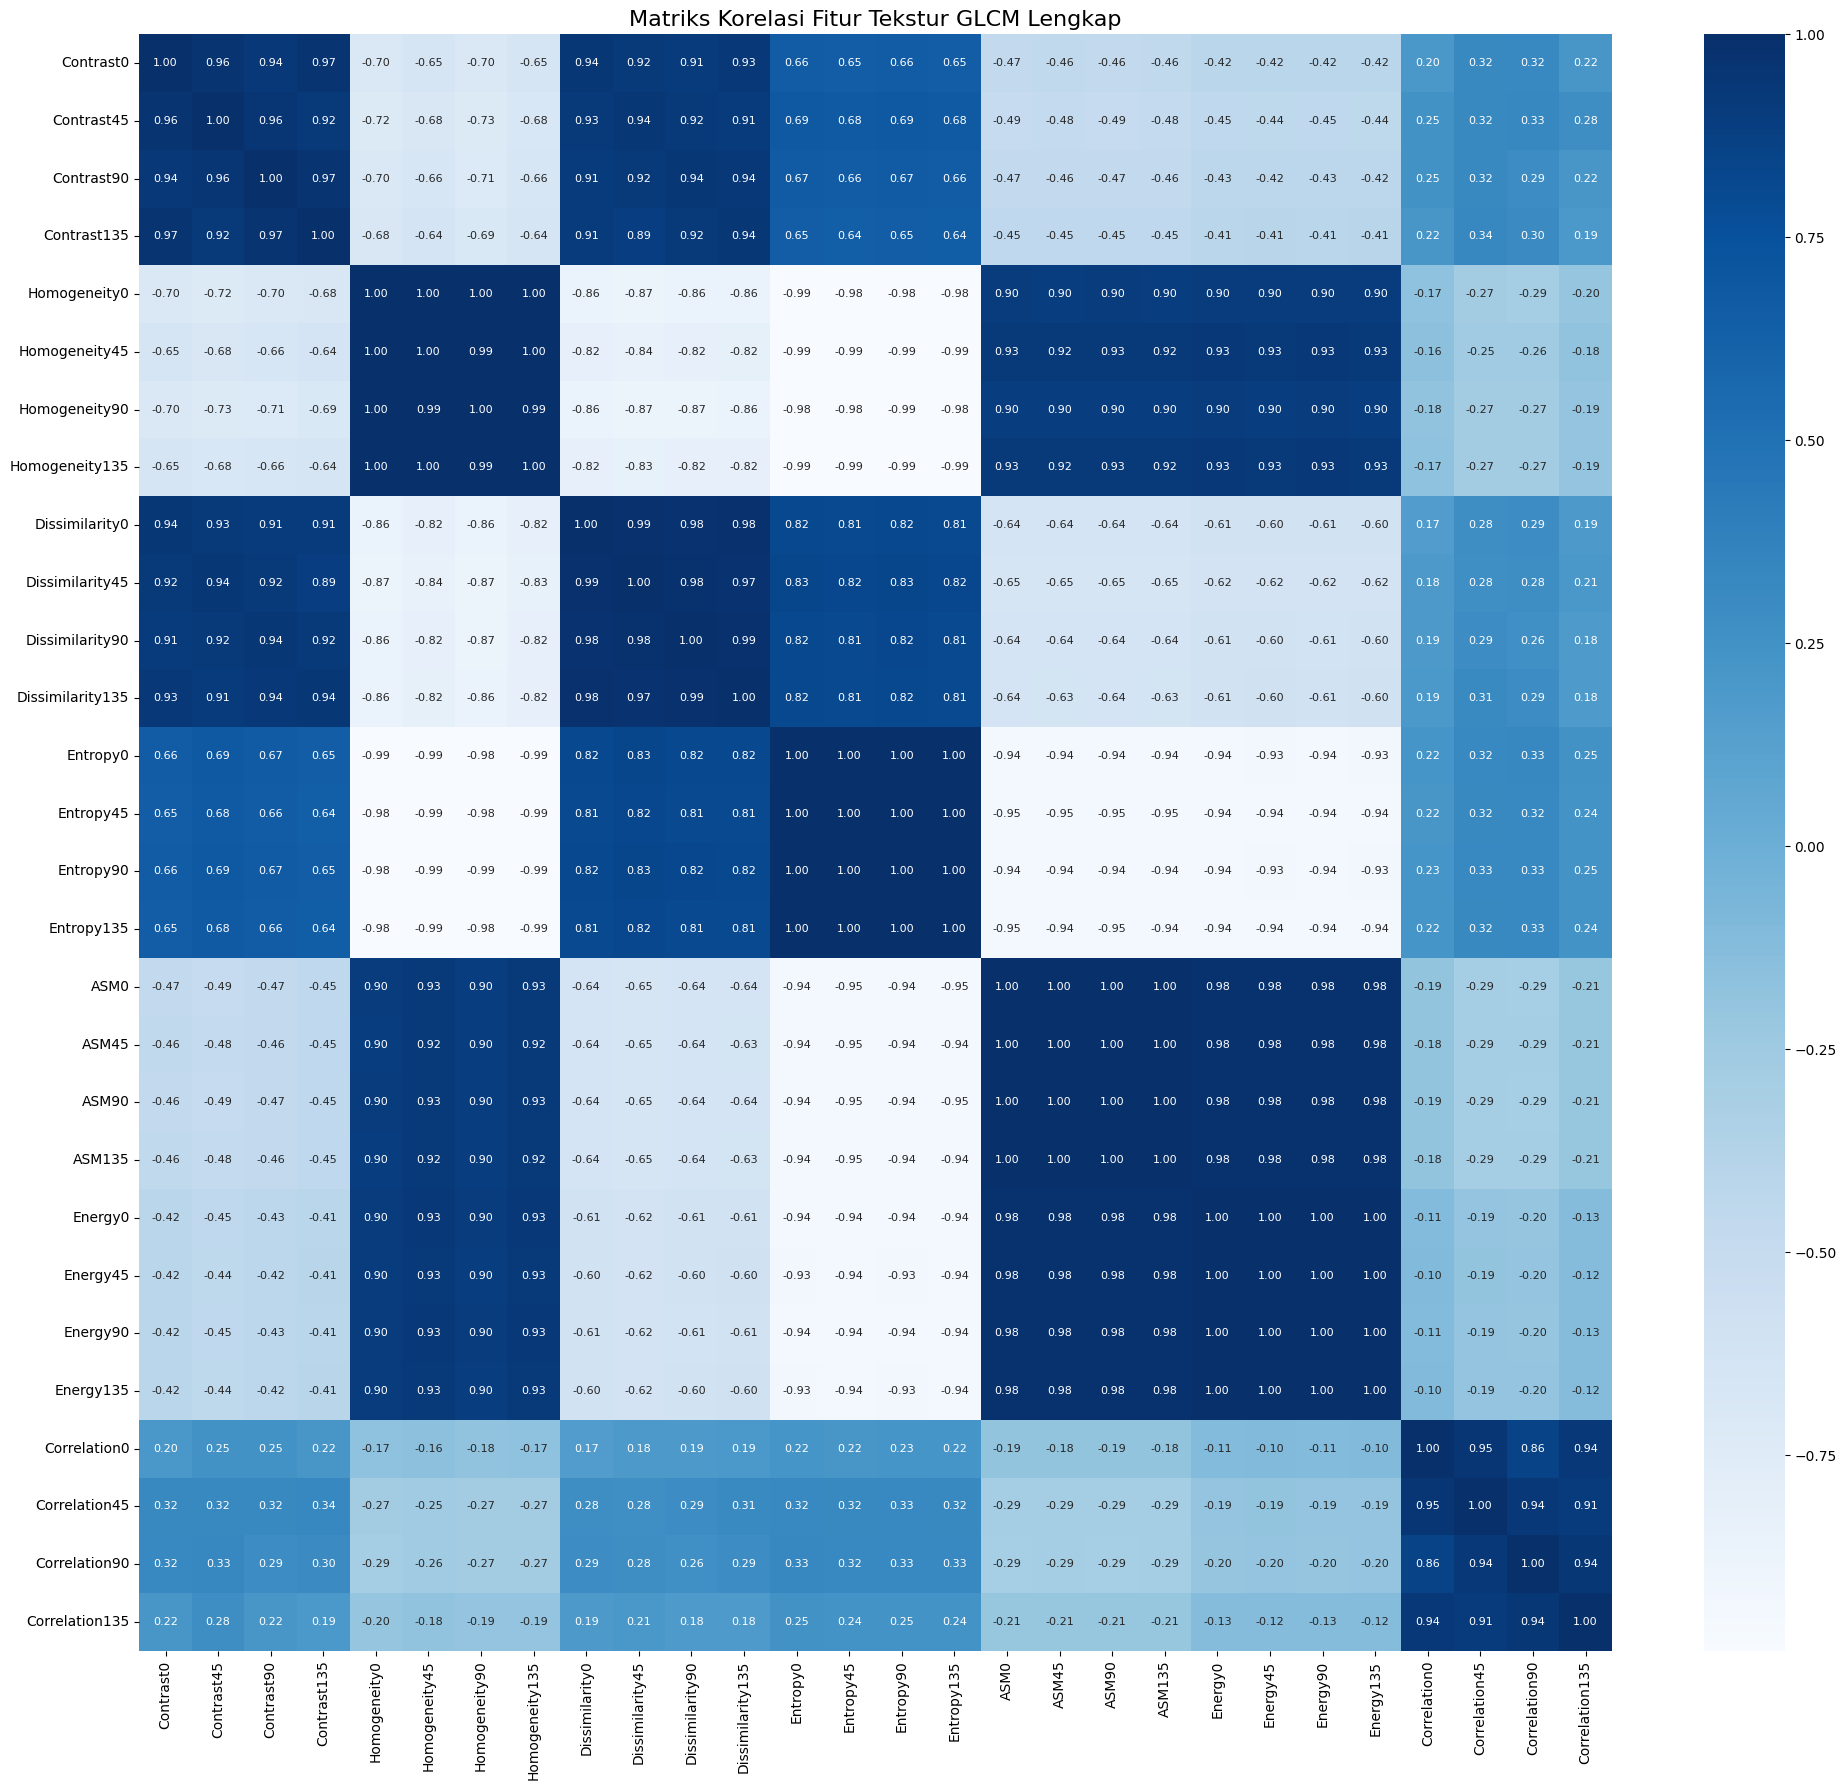

--- HASIL SELEKSI FITUR ---
Jumlah fitur awal : 28 fitur
Jumlah fitur setelah disaring (Korelasi < 0.85) : 3 fitur
Fitur yang terpilih: ['Contrast0', 'Homogeneity0', 'Correlation0']

Akurasi SEBELUM Seleksi Korelasi (28 fitur): 85.00%
Akurasi SETELAH Seleksi Korelasi (3 fitur) : 85.00%


In [32]:
correlation = hasilEkstrak.drop(columns=['Label', 'Filename']).corr()

plt.figure(figsize=(20, 18))
sns.heatmap(correlation, annot=True, cmap='Blues', fmt=".2f", cbar=True, annot_kws={"size": 8})
plt.title("Matriks Korelasi Fitur Tekstur GLCM Lengkap", fontsize=16)
plt.tight_layout()
plt.show()

threshold = 0.85 
columns_mask = np.full((correlation.shape[0],), True, dtype=bool)

for i in range(correlation.shape[0]):
    for j in range(i+1, correlation.shape[0]):
        if abs(correlation.iloc[i, j]) >= threshold:
            if columns_mask[j]:
                columns_mask[j] = False

select = hasilEkstrak.drop(columns=['Label', 'Filename']).columns[columns_mask]

x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"--- HASIL SELEKSI FITUR ---")
print(f"Jumlah fitur awal : {correlation.shape[0]} fitur")
print(f"Jumlah fitur setelah disaring (Korelasi < {threshold}) : {x_new.shape[1]} fitur")
print(f"Fitur yang terpilih: {list(select)}\n")

# Split data menggunakan fitur awal vs fitur baru
X_train_old, X_test_old, y_train, y_test = train_test_split(
    hasilEkstrak.drop(columns=['Label', 'Filename']), y, test_size=0.2, random_state=42
)
X_train_new, X_test_new, _, _ = train_test_split(x_new, y, test_size=0.2, random_state=42)

# Model dengan fitur awal
model_old = RandomForestClassifier(random_state=42)
model_old.fit(X_train_old, y_train)
acc_old = accuracy_score(y_test, model_old.predict(X_test_old))

# Model dengan fitur hasil seleksi
model_new = RandomForestClassifier(random_state=42)
model_new.fit(X_train_new, y_train)
acc_new = accuracy_score(y_test, model_new.predict(X_test_new))

print("="*60)
print(f"Akurasi SEBELUM Seleksi Korelasi ({correlation.shape[0]} fitur): {acc_old * 100:.2f}%")
print(f"Akurasi SETELAH Seleksi Korelasi ({x_new.shape[1]} fitur) : {acc_new * 100:.2f}%")
print("="*60)

### Splitting Data

In [33]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


### Feature Normalization

In [34]:
# normalisasi mean std (Standardization / Z-score normalization)
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Modeling

### Define Model

In [35]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

In [36]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

     Brokoli       0.94      0.96      0.95        79
 Kembang Kol       0.96      0.94      0.95        81

    accuracy                           0.95       160
   macro avg       0.95      0.95      0.95       160
weighted avg       0.95      0.95      0.95       160

[[76  3]
 [ 5 76]]
Accuracy: 0.95

------Testing Set------
              precision    recall  f1-score   support

     Brokoli       0.77      0.95      0.85        21
 Kembang Kol       0.93      0.68      0.79        19

    accuracy                           0.82        40
   macro avg       0.85      0.82      0.82        40
weighted avg       0.84      0.82      0.82        40

[[20  1]
 [ 6 13]]
Accuracy: 0.825


### Train SVM Classifier

In [37]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     Brokoli       0.83      0.90      0.86        79
 Kembang Kol       0.89      0.81      0.85        81

    accuracy                           0.86       160
   macro avg       0.86      0.86      0.86       160
weighted avg       0.86      0.86      0.86       160

[[71  8]
 [15 66]]
Accuracy: 0.85625

------Testing Set------
              precision    recall  f1-score   support

     Brokoli       0.79      0.90      0.84        21
 Kembang Kol       0.88      0.74      0.80        19

    accuracy                           0.82        40
   macro avg       0.83      0.82      0.82        40
weighted avg       0.83      0.82      0.82        40

[[19  2]
 [ 5 14]]
Accuracy: 0.825


### Train KNN Classifier

In [38]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     Brokoli       0.90      0.91      0.91        79
 Kembang Kol       0.91      0.90      0.91        81

    accuracy                           0.91       160
   macro avg       0.91      0.91      0.91       160
weighted avg       0.91      0.91      0.91       160

[[72  7]
 [ 8 73]]
Accuracy: 0.90625

------Testing Set------
              precision    recall  f1-score   support

     Brokoli       0.73      0.90      0.81        21
 Kembang Kol       0.86      0.63      0.73        19

    accuracy                           0.78        40
   macro avg       0.79      0.77      0.77        40
weighted avg       0.79      0.78      0.77        40

[[19  2]
 [ 7 12]]
Accuracy: 0.775


### Evaluasi dengan Confussion Matrix

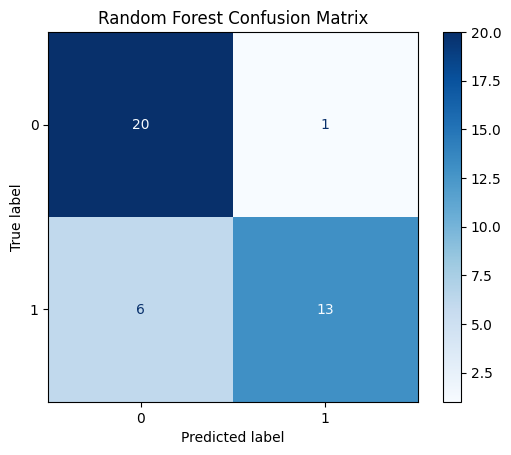

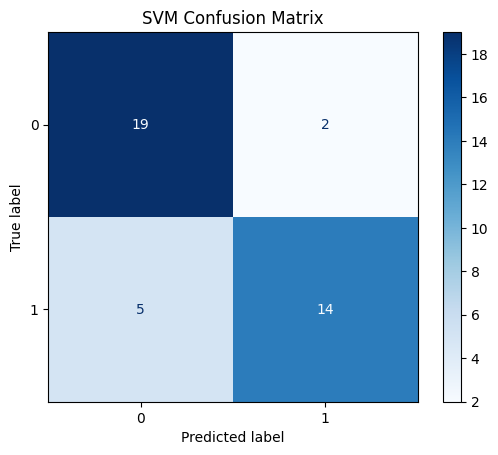

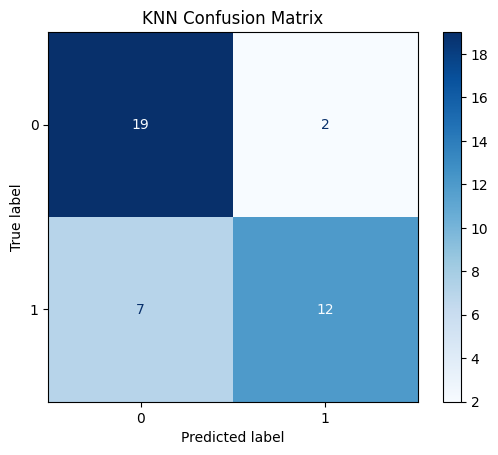

In [39]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")